# Sentiment Analysis 

This notebook analyses the sentiment of the comments.

In [1]:
import numpy as np
import math

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from database.comments import Comments

import sys
sys.path.append('../functions')
from nlp_tasks import NLP_Tasks

import preprocessing_fncs as prep

/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Can use the sentiment analysis pipeline from HuggingFace

In [2]:
cs = Comments(env='dev')
nlp = NLP_Tasks()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


Device set to use mps:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


In [3]:
df = cs.read_all()
df = df.copy()
df = prep.format_df(df, borough_col_name='council')

In [4]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,94578,Barnet,21/3726/FUL_36,21/3726/FUL,13 baxendale london n20 oeg,Objects,2021-11-26,OBJECTIONS\n\n1. My comments submitted already...,2025-04-11,NaN,NaN,OBJECTIONS\n\n1. My comments submitted already...,None,-0.107717
1,80797,Ealing,214950FUL_104,214950FUL,Oakwood ct London W148jf W148jf,Objects,2021-09-15,I have grandchildren attending Ark Byron\nPlea...,2025-04-09,51.499900,-0.207550,I have grandchildren attending \nPlease do not...,E09000020,-0.447377
2,89760,Barnet,23/4531/FUL_7,23/4531/FUL,140 high road East Finchley London N2 9ED,Objects,2023-11-19,"We currently own the building next door, 140, ...",2025-04-10,51.590681,-0.164280,"We currently own the building next door, 140, ...",E09000003,-0.141803
3,75195,Barnet,23/3688/FUL_1,23/3688/FUL,63 Lodge Lane London N12 8JG,Objects,2023-10-06,"Dear Sir/ Madam,\nApologies for missing the on...",2025-04-07,51.616629,-0.177801,"Dear Sir/ Madam,\nApologies for missing the on...",E09000003,-0.219902
4,92152,Ealing,215983FUL_416,215983FUL,51 Manton Avenue Hanwell W7 2DY W7 2DY,Objects,2021-11-11,I am distressed to see a building proposal app...,2025-04-10,51.504120,-0.329371,I am distressed to see a building proposal app...,E09000009,-0.326843


### Plot histograms of sentiment score 

In [5]:
# sns colour palette for stance 
stance_palette = {
    'Supports': '#426acf',  # blue
    'Objects': '#cf4242',   # orange
    'Neutral': '#b8cd73'    # green
}

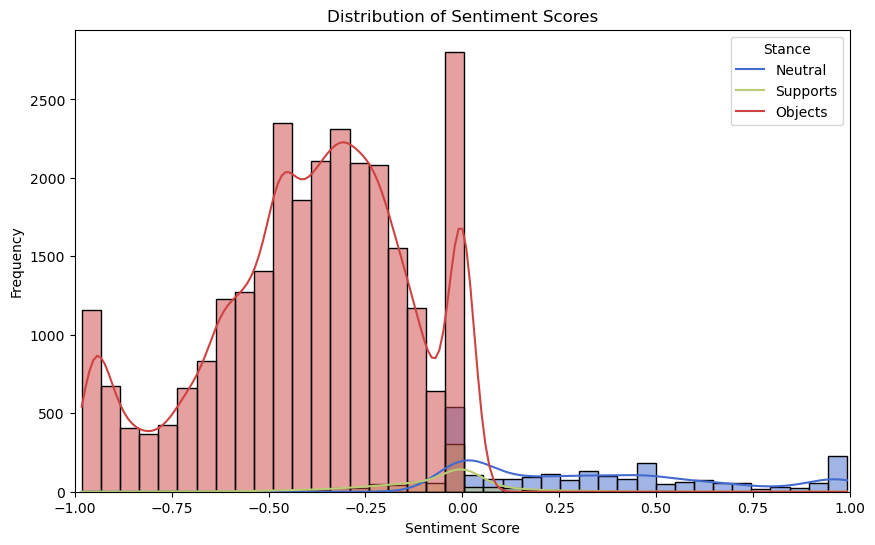

In [6]:
# Plot histogram of sentiment scores

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="sentiment_score", bins=40, kde=True, hue="stance", legend=True, palette=stance_palette)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.xlim(-1, 1)
plt.legend(title='Stance', loc='upper right', labels=['Neutral', 'Supports', 'Objects'])
# plt.axvline(x=0, color='red', linestyle='--', label='Neutral')
# plt.legend()
plt.show()

### Sentiment score by council 

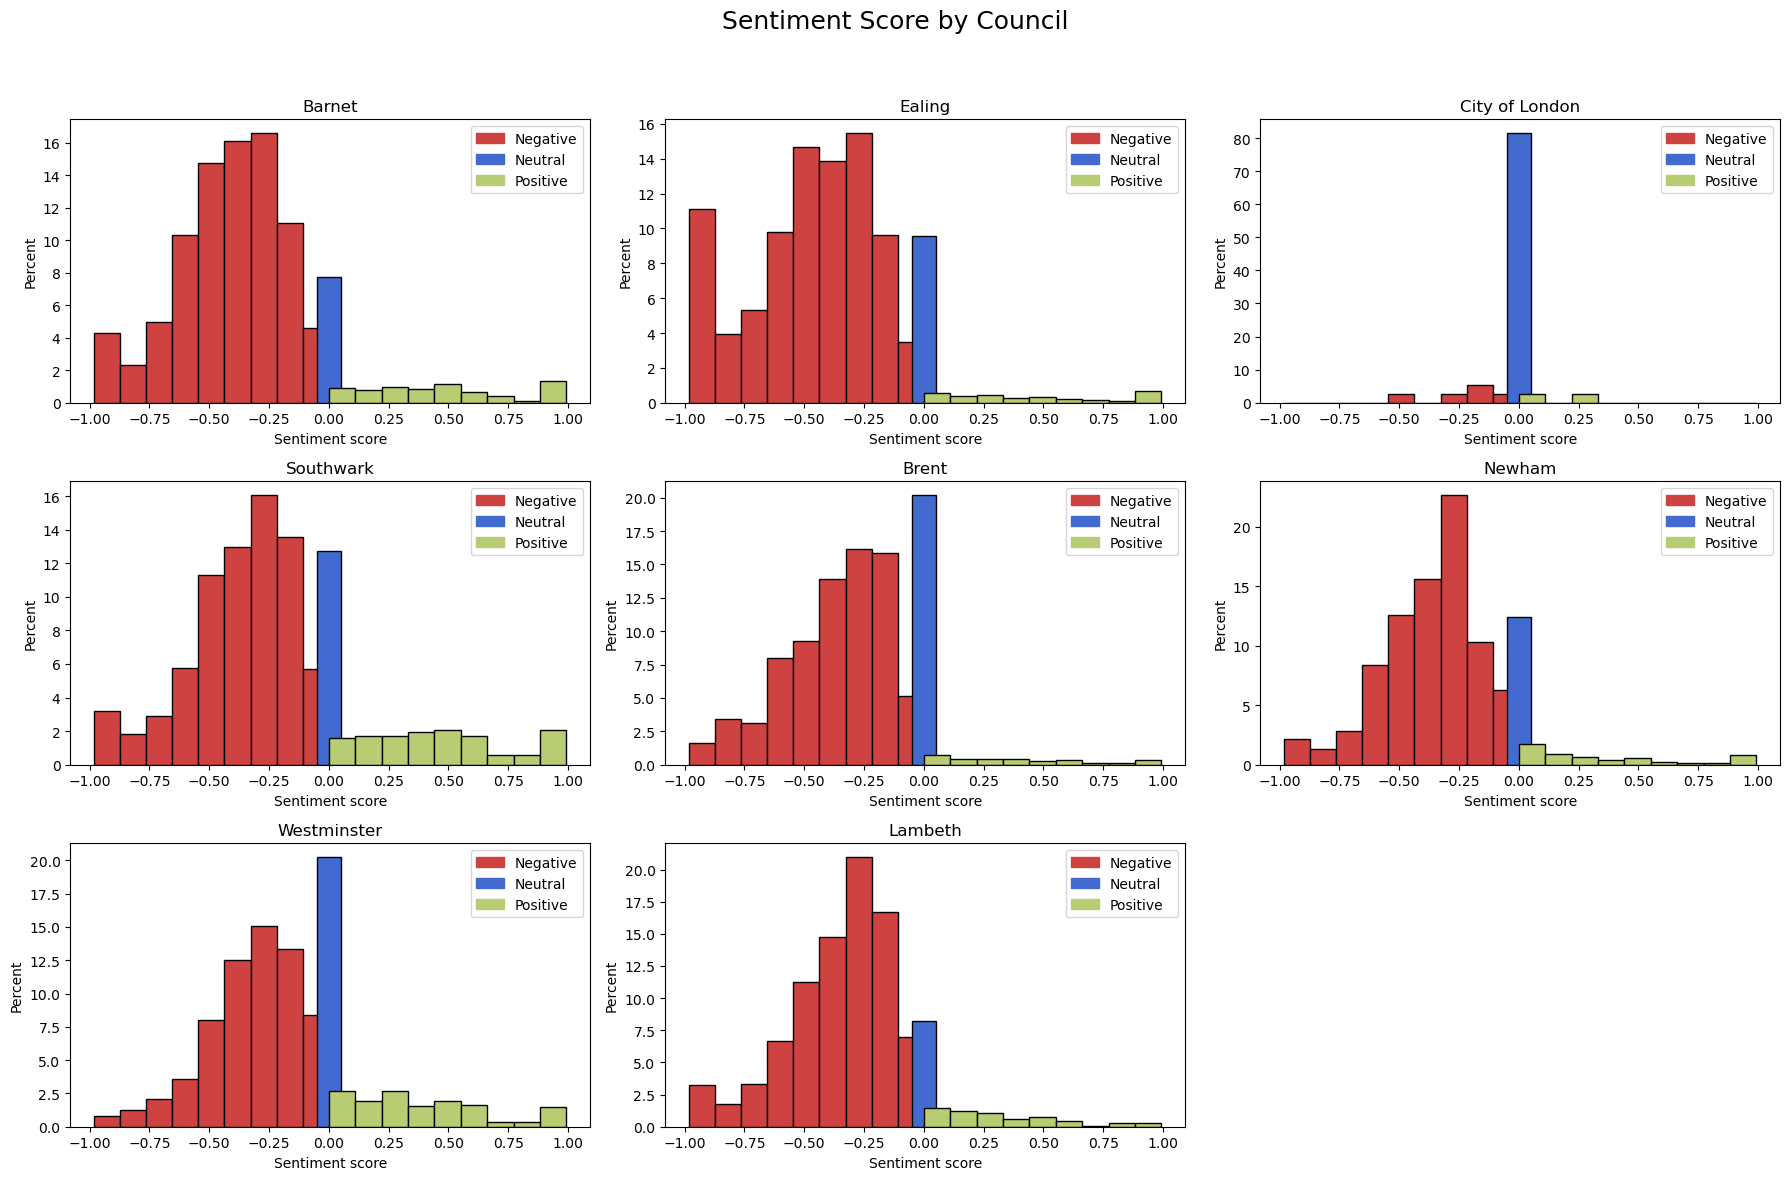

In [7]:
councils = df['council'].unique()

cols = 3
rows = math.ceil(len(councils) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axes = axes.flatten()

neg_bins = np.linspace(df['sentiment_score'].min(), -0.0001, 10)
pos_bins = np.linspace(0.0001, df['sentiment_score'].max(), 10)

for ax, council in zip(axes, councils):
    council_df = df[df['council'] == council]
    scores = council_df['sentiment_score'].dropna()
    total = len(scores)

    zeros = (scores == 0).sum()
    neg_scores = scores[scores < 0]
    pos_scores = scores[scores > 0]

    # Histogram for negative and positive values
    neg_counts, neg_edges = np.histogram(neg_scores, bins=neg_bins)
    pos_counts, pos_edges = np.histogram(pos_scores, bins=pos_bins)

    neg_perc = neg_counts / total * 100
    pos_perc = pos_counts / total * 100
    zero_perc = zeros / total * 100

    # Plot negative bins (red)
    ax.bar(neg_edges[:-1], neg_perc, width=np.diff(neg_edges), color="#cf4242", edgecolor='black', align='edge')

    # Plot zero bin (blue)
    if zero_perc > 0:
        ax.bar(0, zero_perc, width=0.1, color="#426acf", edgecolor='black', align='center')

    # Plot positive bins (green)
    ax.bar(pos_edges[:-1], pos_perc, width=np.diff(pos_edges), color="#b8cd73", edgecolor='black', align='edge')

    ax.set_title(council)
    ax.set_xlabel('Sentiment score')
    ax.set_ylabel('Percent')

    # Add a nice legend using Patch handles
    handles = [
        mpatches.Patch(color="#cf4242", label='Negative'),
        mpatches.Patch(color="#426acf", label='Neutral'),
        mpatches.Patch(color="#b8cd73", label='Positive')
    ]
    ax.legend(handles=handles, loc='upper right')

# Hide unused axes
for i in range(len(councils), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle('Sentiment Score by Council', fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../results/figures/sentiment_by_council.png', dpi=500)
plt.show()
